Name: Hissah Alkharboush

Fast Food Marketing Campaign A/B Test

Overveiw

The primary objective is to assist the fast-food chain in making a data-driven decision to select the most successful marketing campaign among three available options, ensuring the highest possible sales upon the official launch of the new product.

Goal:
Evaluate A/B testing results and decide which marketing strategy works the best

I will start with EDA :

In [13]:
#import the libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [14]:
#import data
data = "WA_Marketing-Campaign.csv"

In [20]:
#Using a data as dataset
food_marketing = pd.read_csv(data)
food_marketing.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [17]:
food_marketing.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


Try ..

In [22]:
food_marketing.groupby(['MarketSize']).mean()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
MarketSize,,,,,,
Large,6.333333,544.357143,7.142857,1.952381,2.5,70.116726
Medium,5.862500,493.550000,8.787500,2.062500,2.5,43.985344
Small,3.200000,224.400000,10.800000,2.066667,2.5,57.409333


.....

First Hypothesis: Promotion Effectiveness on Sales Performance.

The goal of this hypothesis is to determine which of the three marketing campaigns (Promotion 1, 2, or 3) has the greatest impact on sales volume by comparing their mean performance.

In [27]:
promotion_mean = food_marketing.groupby('Promotion')['SalesInThousands'].mean()
promotion_mean

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

Using visualization to present the hypothesis in a different way:

C:\Users\96654\AppData\Local\Temp\ipykernel_31452\4008060825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promotion_mean.index, y=promotion_mean.values, palette='viridis')


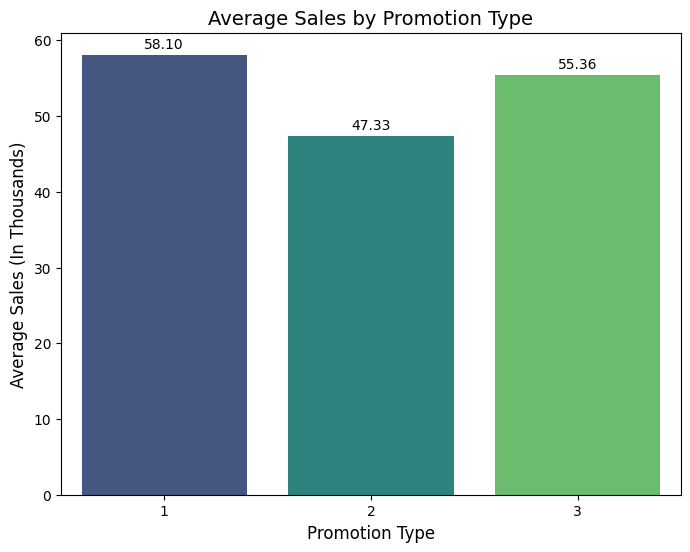

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(x=promotion_mean.index, y=promotion_mean.values, palette='viridis')

plt.title('Average Sales by Promotion Type', fontsize=14)
plt.xlabel('Promotion Type', fontsize=12)
plt.ylabel('Average Sales (In Thousands)', fontsize=12)

for i, value in enumerate(promotion_mean.values):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center', va='bottom')

plt.show()

The diagram shows that the first promotion has a higher mean than the others. To confirm this hypothesis, we should validate it using CDA (Confirmatory Data Analysis)

In [ ]:
promo1 = food_marketing[food_marketing['Promotion'] == 1]['SalesInThousands']
promo2 = food_marketing[food_marketing['Promotion'] == 2]['SalesInThousands']
promo3 = food_marketing[food_marketing['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)

#print(f"F-Statistic: {f_stat:.4f}")
#print(f"P-Value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    # Reject the null hypothesis because the difference is statistically significant
    print("Result: There is a statistically significant difference between the campaigns.")
else:
    # Fail to reject the null hypothesis because the difference is not significant
    print("Result: There is no statistically significant difference between the campaigns.")

F-Statistic: 21.9535
P-Value: 0.0000
Result: There is a statistically significant difference between the campaigns.


Second Hypothesis: Market Size Impact on Sales Performance.

The goal of this hypothesis is to determine if the scale of the market (Small, Medium, or Large) significantly influences the volume of sales, regardless of the promotion used.

In [31]:
market_size_mean = food_marketing.groupby('MarketSize')['SalesInThousands'].mean()
market_size_mean

MarketSize
Large     70.116726
Medium    43.985344
Small     57.409333
Name: SalesInThousands, dtype: float64

C:\Users\96654\AppData\Local\Temp\ipykernel_31452\848918841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_size_mean.index, y=market_size_mean.values, palette='magma')


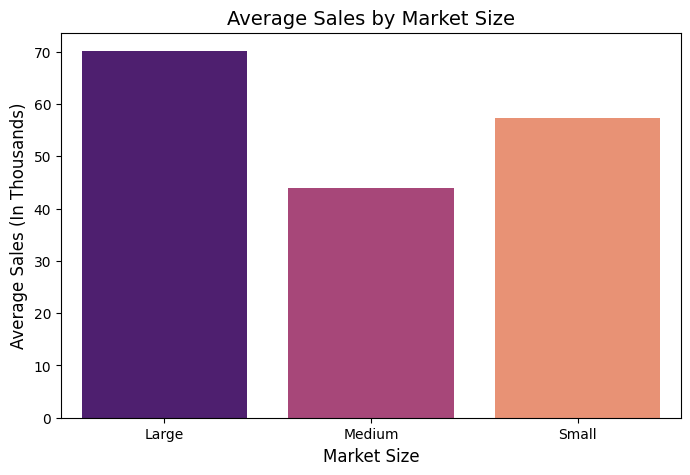

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(x=market_size_mean.index, y=market_size_mean.values, palette='magma')

plt.title('Average Sales by Market Size', fontsize=14)
plt.xlabel('Market Size', fontsize=12)
plt.ylabel('Average Sales (In Thousands)', fontsize=12)

plt.show()

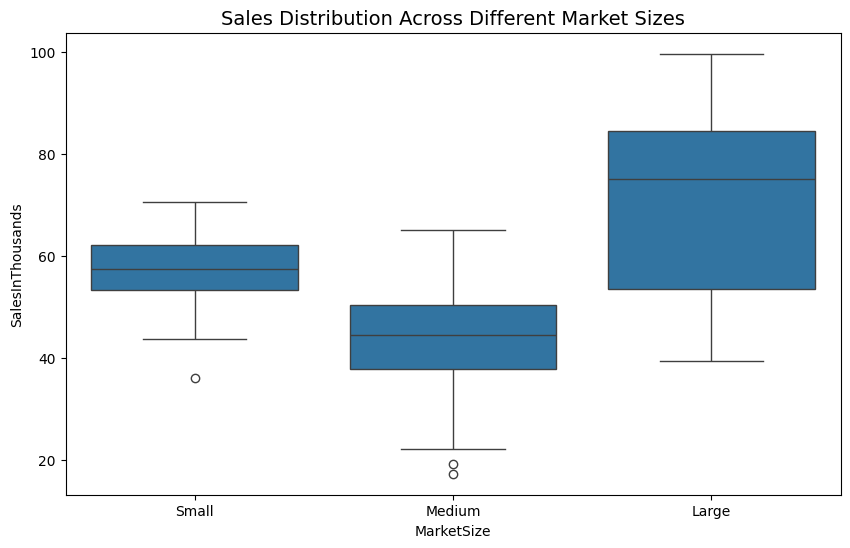

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='MarketSize', y='SalesInThousands', data=food_marketing, order=['Small', 'Medium', 'Large'])

plt.title('Sales Distribution Across Different Market Sizes', fontsize=14)
plt.show()

In [36]:
large_market_variance = food_marketing[food_marketing['MarketSize'] == 'Large']['SalesInThousands'].var()

print(f"Variance for Large Market Sales: {large_market_variance:.2f}")

Variance for Large Market Sales: 290.78


The diagram illustrates the average sales across different market sizes. We can observe how market scale impacts the overall performance of the promotions

In [35]:
small_market = food_marketing[food_marketing['MarketSize'] == 'Small']['SalesInThousands']
medium_market = food_marketing[food_marketing['MarketSize'] == 'Medium']['SalesInThousands']
large_market = food_marketing[food_marketing['MarketSize'] == 'Large']['SalesInThousands']

f_stat, p_value = stats.f_oneway(small_market, medium_market, large_market)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Result: Market size has a statistically significant impact on sales.")
else:
    print("Result:No significant difference found between market sizes.")

F-Statistic: 268.9130
P-Value: 0.0000
Result: Market size has a statistically significant impact on sales.


Third Hypothesis: Store Age Impact on Sales Performance

The goal of this hypothesis is to determine if there is a correlation between the age of a store and the volume of sales for the new product.

In [37]:
correlation = food_marketing['AgeOfStore'].corr(food_marketing['SalesInThousands'])

print(f"Correlation between Age and Sales: {correlation:.4f}")

Correlation between Age and Sales: -0.0285


Conclusion for Hypothesis 3: The correlation coefficient between store age and sales is approximately -0.0285. This indicates a negligible relationship, suggesting that the age of the store does not play a significant role in the success of the new promotion.

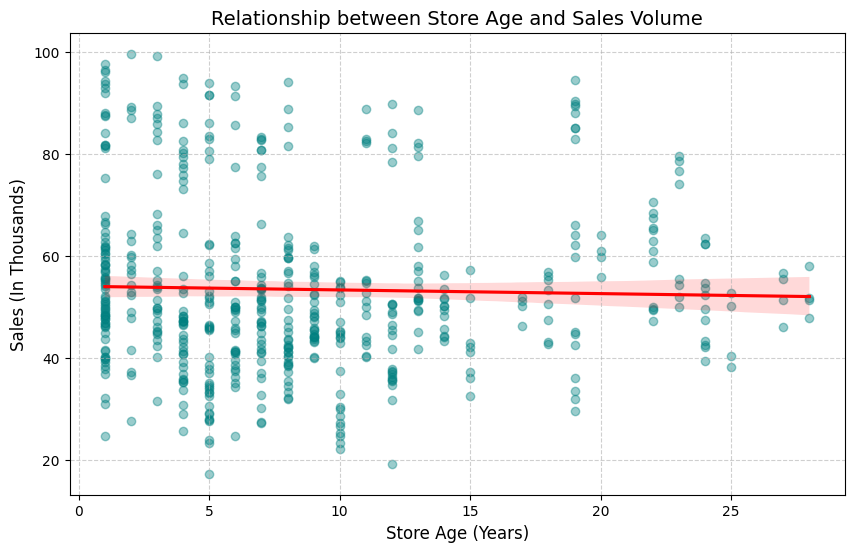

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(data=food_marketing, x='AgeOfStore', y='SalesInThousands', 
            scatter_kws={'alpha':0.4, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Relationship between Store Age and Sales Volume', fontsize=14)
plt.xlabel('Store Age (Years)', fontsize=12)
plt.ylabel('Sales (In Thousands)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

The scatter plot confirms the correlation result. The horizontal trend line indicates that there is no meaningful relationship between the age of the store and its sales performance, proving that the promotion's success is independent of store seniority.